In [81]:
# Importing relevant libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

In [82]:
data_path = "OneDrive_3_10-3-2025"

In [83]:
folder = Path(data_path)
files = sorted(list(folder.glob("*.csv")) + list(folder.glob("*.xlsx")))
df_main = pd.DataFrame(columns=['Contact Session ID', 'EP Name', 'Flow Name', 'Activity Name', 'Activity Start Timestamp', 
                                'Queue Name', 'Agent Name', 'Termination Reason'])
df_main

,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason


In [84]:
i=0
for f in files:
    i = i + 1
    if f.suffix.lower() == ".csv":
        df = pd.read_csv(f, header=2, dtype=str, engine="python", skip_blank_lines=False)
    else:  # .xlsx
        df = pd.read_excel(f, sheet_name=0, header=2, dtype=str)
    df_main = pd.concat([df_main, df], ignore_index=True)
    print(i, f.stem, df.shape)

1 CAR - EP, Flow, Activity, Queue, & Agent Names (01-12-25 - 01-18-25) (52010, 7)
2 CAR - EP, Flow, Activity, Queue, & Agent Names (01-19-25 - 02-01-25) (95495, 7)
3 CAR - EP, Flow, Activity, Queue, & Agent Names (02-02-25 - 02-15-25) (90056, 7)
4 CAR - EP, Flow, Activity, Queue, & Agent Names (02-16-25 - 03-01-25) (88186, 7)
5 CAR - EP, Flow, Activity, Queue, & Agent Names (03-02-25 - 03-15-25) (86377, 7)
6 CAR - EP, Flow, Activity, Queue, & Agent Names (04-07-24 - 04-20-24) (88766, 7)
7 CAR - EP, Flow, Activity, Queue, & Agent Names (04-21-24 - 05-04-24) (89643, 7)
8 CAR - EP, Flow, Activity, Queue, & Agent Names (05-05-24 - 05-18-24) (82575, 7)
9 CAR - EP, Flow, Activity, Queue, & Agent Names (05-19-24 - 06-01-24) (71103, 7)
10 CAR - EP, Flow, Activity, Queue, & Agent Names (06-02-24 - 06-15-24) (84354, 7)
11 CAR - EP, Flow, Activity, Queue, & Agent Names (06-16-24 - 06-29-24) (82124, 7)
12 CAR - EP, Flow, Activity, Queue, & Agent Names (06-30-24 - 07-13-24) (79752, 7)
13 CAR - EP, 

In [85]:
df_main['Contact Session ID'].nunique()

248442

In [86]:
df_main['Activity Start Timestamp'] = pd.to_datetime(df_main['Activity Start Timestamp'], errors='coerce')

In [87]:
# Basic overview of 'EP Name' values
df_main['EP Name'].value_counts(dropna=False)

EP Name
Main Number Telephony EP                    1239571
NaN                                          791408
Legal Menu Telephony EP                      245849
Pre-Legal Menu Seniors Menu Telephony EP     232691
Closed Queue Menu Telephony EP               174367
All LAC Queues Telephony EP                  131109
Courtesy Callback Telephony EP                88625
Closed Hours-Holidays Menu Telephony EP       79720
Other Legal Menu Telephony EP                 72372
Legal Housing Menu Telephony EP               68447
Intake Outdial EP                             65456
Legal Family Menu Telephony EP                54772
Farmworker Main Number Telephony EP           52968
Legal Benefits Menu Telephony EP               9253
Legal HIV Menu Telephony EP                    8463
Legal Immigration Menu Telephony EP            7861
Legal Employment Menu Telephony EP             5694
Name: count, dtype: int64

In [88]:
# Create a smaller DataFrame for only Benefits Menu data
df_benefits_only = df_main[df_main['EP Name'] == 'Legal Benefits Menu Telephony EP'].copy()

In [89]:
# Step 1: Get all unique Contact Session IDs that went through the Benefits menu
benefits_sessions = df_benefits_only['Contact Session ID'].unique()

# Step 2: Filter df_main to only include those same sessions
df_benefits_fullpath = df_main[df_main['Contact Session ID'].isin(benefits_sessions)].copy()

# Step 3: sort chronologically to see the call flow order
df_benefits = df_benefits_fullpath.sort_values(
    by=['Contact Session ID', 'Activity Start Timestamp']
).reset_index(drop=True)

In [90]:
import numpy as np

# Sort by Contact Session ID and timestamp so "last" is truly the most recent
df_benefits = df_benefits.sort_values(by=['Contact Session ID', 'Activity Start Timestamp'])

# Identify the last EP Name per Contact Session ID
last_ep = (
    df_benefits.groupby('Contact Session ID')['EP Name']
    .last()
    .reset_index()
    .rename(columns={'EP Name': 'Last_EP_Name'})
)

# Merge that back to the main df_benefits
df_benefits = df_benefits.merge(last_ep, on='Contact Session ID', how='left')

# Create Yes/No or 1/0 indicator
df_benefits['Ended_in_Benefits_EP'] = np.where(
    df_benefits['Last_EP_Name'] == 'Legal Benefits Menu Telephony EP', 'Yes', 'No'
)

In [91]:
df_benefits['Contact Session ID'].nunique()

7408

In [92]:
# For each Contact Session ID, take the last non-null Activity Name
df_benefits['Last_NonNull_Activity'] = (
    df_benefits
      .groupby('Contact Session ID')['Activity Name']
      .transform(lambda s: s.dropna().iloc[-1] if s.notna().any() else np.nan)
)

In [93]:
# 1) Get unique Contact Session ID + their last non-null activity
last_activity_per_session = (
    df_benefits[['Contact Session ID', 'Last_NonNull_Activity']]
    .drop_duplicates(subset='Contact Session ID')
)

# 2) Count how many sessions ended in each activity
activity_end_counts = (
    last_activity_per_session['Last_NonNull_Activity']
    .value_counts(dropna=False)
    .reset_index()
    .rename(columns={'index': 'Activity Name', 'Last_NonNull_Activity': 'Unique Contact Sessions'})
)

In [94]:
activity_end_counts

,Unique Contact Sessions,count
0,ClosedQueueMenu,4731
1,ClinicVoicemailTransfer,837
2,LegalServerScreenPop,726
3,DisconnectContact1,338
4,BenefitsMenu,298
5,VeteransBenefitsVoicemailTransfer,185
6,QueueMenu1,75
7,LegalMenu2,55
8,ScreenPopProcessComplete,43
9,PlayMOH300s,41


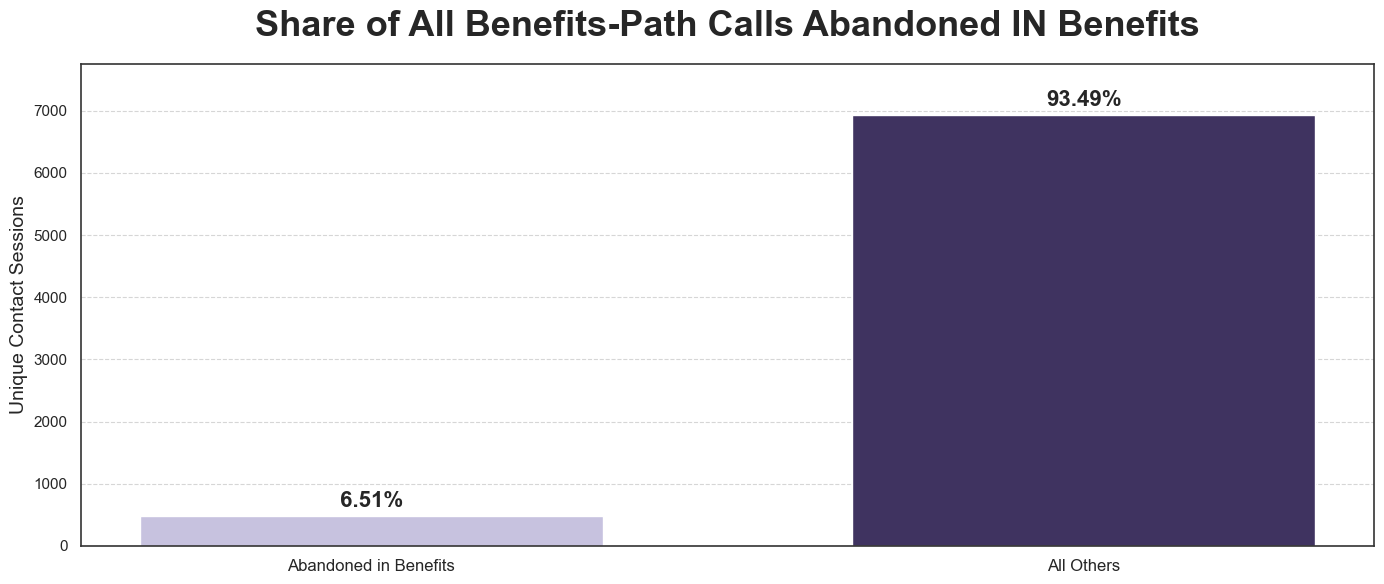

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# ---- Data (Benefits version) ----
session_outcome = (
    df_benefits[['Contact Session ID', 'Ended_in_Benefits_EP']]
    .drop_duplicates(subset='Contact Session ID')
)

counts = session_outcome['Ended_in_Benefits_EP'].value_counts()

abandoned = counts.get('Yes', 0)
others = counts.get('No', 0)

plot_df = pd.DataFrame({
    "Outcome": ["Abandoned in Benefits", "All Others"],
    "Unique Contact Sessions": [abandoned, others]
})

plot_df["Percent"] = (
    plot_df["Unique Contact Sessions"] /
    plot_df["Unique Contact Sessions"].sum() * 100
)

# ---- Exact Seniors Chart Colors ----
light_lavender = "#c7c2df"
deep_purple = "#3f3360"
colors = [light_lavender, deep_purple]

fig, ax = plt.subplots(figsize=(14, 6))

# ---- Bar Style Identical to Seniors ----
bars = ax.bar(
    plot_df["Outcome"],
    plot_df["Unique Contact Sessions"],
    color=colors,
    width=0.65         # thicker bars
)

max_count = plot_df["Unique Contact Sessions"].max()
ax.set_ylim(0, max_count * 1.12)

# ---- Title ----
ax.set_title(
    "Share of All Benefits-Path Calls Abandoned IN Benefits",
    fontsize=26,
    fontweight="bold",
    pad=20
)

ax.set_ylabel("Unique Contact Sessions", fontsize=14)
ax.set_xlabel("")

# ---- Seniors-style dashed grid ----
ax.yaxis.grid(True, linestyle="--", linewidth=0.8, alpha=0.8)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

# ---- FULL BORDER (Seniors style) ----
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_color("#333333")

# ---- Percent Labels (same placement as Seniors) ----
for bar, pct in zip(bars, plot_df["Percent"]):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + (max_count * 0.012),
        f"{pct:.2f}%",
        ha="center",
        va="bottom",
        fontsize=16,
        fontweight="bold"
    )

# ---- Tick Formatting ----
ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=11)

plt.tight_layout()
plt.show()
